In [3]:
%pip install polars



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.7/828.7 kB 9.5 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 MB 53.4 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [14]:
from io import StringIO

import requests
import polars as pl
import seaborn as sns 
import matplotlib.pyplot as plt

In [5]:
# Define API query URL (CSV with labels format)
url = 'https://sdmx.oecd.org/public/rest/data/OECD.WISE.CWB,DSD_CWB@DF_CWB,/all?dimensionAtObservation=AllDimensions&format=csvfile'
# Fetch data
response = requests.get(url)

# Load into polars DataFrame
df = pl.read_csv(StringIO(response.text))

In [6]:
# Filters

## Keep only the measures with the lowest number of missing values for the years 2009,2012,2015,2018
measures = [
    'A1_2','A1_4', #Material outcome
    'A2_1', # Physical health outcome
    'A3_3','A3_4','A3_5', #Cognitive & educational outcome
    'A4_6', #Social & emotional outcome
    'B1_1','B1_5', #Home & Family Life
    'B2_1','B2_4','B2_5', #Life at school & early education and care
    'B3_5', #Social Life and life in the community
    'B4_3', #Life online
    'C1_1','C1_2','C1_3','C1_4','C1_5', #Family policies
    'C2_1','C2_2','C2_3', #House & Community policies
    'C3_1','C3_2','C3_3', #Health policies
    'C4_1','C4_2','C4_3','C4_4','C4_5','C4_6', #Education & eary childhood policies
    'C5_1', #Environmental policies
]

## Keep only the European countries
areas = [
    'SWE', 'DNK', 'NOR', 'FIN', 'ISL', 'LTU', 'LVA', 'EST', #Northern Europe
    'IRL', 'GBR', 'NLD', 'BEL', 'FRA', 'LUX', 'CHE', 'AUT', 'DEU', #Western Europe
    'ESP', 'PRT', 'ITA', 'GRC', 'SVN', 'HRV', 'TUR', #Southern Europe
    'POL', 'CZE', 'SVK', 'HUN', 'ROU', 'BGR', #Eastern Europe
]

## Keep only a subset of years
years = [2009, 2012, 2015, 2018]

In [7]:
# Apply the filters on the dataframe
df = df.filter(
    pl.col('MEASURE').is_in(measures) &
    pl.col('REF_AREA').is_in(areas) &
    pl.col('TIME_PERIOD').is_in(years)
)

In [8]:
df.head(10)

DATAFLOW,REF_AREA,MEASURE,DOMAIN,TIME_PERIOD,OBS_VALUE,OBS_STATUS,UNIT_MULT,UNIT_MEASURE,BASE_PER,DECIMALS,POP_GROUP
str,str,str,str,i64,f64,str,i64,str,i64,i64,str
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""AUT""","""C2_1""","""C2""",2009,204.6,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""AUT""","""C2_1""","""C2""",2012,186.1,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""AUT""","""C2_1""","""C2""",2015,175.4,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""AUT""","""C2_1""","""C2""",2018,169.8,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""BEL""","""C2_1""","""C2""",2009,182.4,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""BEL""","""C2_1""","""C2""",2012,184.7,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""BEL""","""C2_1""","""C2""",2015,130.7,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""BEL""","""C2_1""","""C2""",2018,162.4,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""
"""OECD.WISE.CWB:DSD_CWB@DF_CWB(1…","""CZE""","""C2_1""","""C2""",2009,305.8,"""A""",0,"""USD_PPP""",2015,1,"""_Z"""


In [9]:
# Create a grid with all the combinations of area and time period
df_grid = pl.DataFrame()

years = df.select('TIME_PERIOD').unique().to_series().to_list()

for area in areas:
    for year in years:
        df_grid = df_grid.vstack(
            pl.DataFrame(
                {
                    'REF_AREA': area,
                    'TIME_PERIOD': year,
                }
            )
        )

#Populate the grid with the measures in a wide format
for measure in measures:
    df_temp = df.filter(
        pl.col('MEASURE') == measure
    ).select(
        ['REF_AREA', 'TIME_PERIOD', 'OBS_VALUE']
    ).with_columns(
        pl.col('OBS_VALUE').alias(measure)
    ).select(
        ['REF_AREA', 'TIME_PERIOD', measure]
    )
    df_grid = df_grid.join(
        df_temp,
        on=['REF_AREA', 'TIME_PERIOD'],
        how='left'
    )

In [10]:
df_grid.head(10)


REF_AREA,TIME_PERIOD,A1_2,A1_4,A2_1,A3_3,A3_4,A3_5,A4_6,B1_1,B1_5,B2_1,B2_4,B2_5,B3_5,B4_3,C1_1,C1_2,C1_3,C1_4,C1_5,C2_1,C2_2,C2_3,C3_1,C3_2,C3_3,C4_1,C4_2,C4_3,C4_4,C4_5,C4_6,C5_1
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""SWE""",2015,4.4,1.7,2.5,16.7,58.9,9.1,null,9.1,59.5,null,17.9,69.3,12.4,37.4,9818.3,7.0,37.0,60.0,10.0,289.1,621.9,155.9,4201.5,98.0,98.0,10716.7,5.0,6.4,11581.8,1220.3,13.4,208.7
"""SWE""",2012,2.4,0.7,2.6,12.4,null,9.7,null,null,null,null,null,null,11.7,null,9748.8,null,39.0,60.0,10.0,242.6,603.6,154.0,3960.1,98.0,98.0,10194.2,6.0,null,11262.5,null,null,214.1
"""SWE""",2009,null,1.5,2.5,15.9,null,11.0,null,null,null,null,null,null,null,null,9185.3,null,41.0,60.0,10.0,259.4,580.5,134.9,3026.3,98.0,97.0,9525.1,null,null,10602.2,null,null,204.8
"""SWE""",2018,5.0,1.0,2.0,19.4,69.8,8.9,32.6,9.0,46.4,46.3,19.2,67.0,15.5,33.5,null,6.9,37.0,55.7,14.3,362.5,635.5,143.3,4389.6,97.0,97.0,null,5.0,6.3,12368.5,1254.5,12.3,252.8
"""DNK""",2015,4.1,0.5,3.7,14.9,40.6,11.4,null,2.9,50.4,null,20.1,70.3,5.3,46.5,10226.9,10.1,63.0,50.0,2.0,115.7,863.5,345.1,3934.1,90.0,88.0,10179.8,11.0,null,null,null,null,207.5
"""DNK""",2012,2.8,0.4,3.4,12.5,null,13.3,null,2.7,null,null,null,null,8.6,null,10300.6,9.6,63.0,50.0,2.0,133.8,871.2,331.5,3755.0,91.0,87.0,10408.6,12.0,null,11820.4,null,null,189.9
"""DNK""",2009,null,1.1,3.1,13.9,null,8.8,null,null,null,null,null,null,null,null,10374.4,null,61.0,50.0,2.0,234.4,866.0,313.9,3824.1,89.0,84.0,9424.0,null,null,12717.1,null,null,204.8
"""DNK""",2018,4.1,0.3,3.7,15.8,64.0,12.0,null,4.9,46.4,56.0,21.4,72.0,5.2,42.7,null,7.2,58.0,50.0,2.0,119.6,845.9,342.7,4084.6,96.0,94.0,null,11.0,6.8,10140.2,43.8,11.3,206.6
"""NOR""",2015,0.8,1.1,2.2,17.6,61.4,9.2,null,7.3,57.0,null,17.6,75.7,4.8,null,11380.7,6.0,39.0,91.0,10.0,456.5,983.4,74.2,4897.3,95.0,95.0,11152.0,7.0,16.0,13993.4,492.8,9.9,534.8


In [11]:
df_grid.write_parquet('../data/child_well_being-grid.parquet')

Analisi dei missing

In [13]:
# Conto null per ogni colonna e calcolo la percentuale.
n_rows = df_grid.height

missing = (
    df_grid.null_count()                         
           .transpose(include_header=True,
                      header_name="colonna",
                      column_names=["n_missing"])
           .with_columns(
               (pl.col("n_missing") / n_rows * 100).round(2).alias("pct_missing")
           )
           .sort("pct_missing", descending=True)
)
print(missing)


shape: (34, 3)
┌─────────────┬───────────┬─────────────┐
│ colonna     ┆ n_missing ┆ pct_missing │
│ ---         ┆ ---       ┆ ---         │
│ str         ┆ u32       ┆ f64         │
╞═════════════╪═══════════╪═════════════╡
│ C4_6        ┆ 73        ┆ 60.83       │
│ A4_6        ┆ 68        ┆ 56.67       │
│ B4_3        ┆ 67        ┆ 55.83       │
│ C4_3        ┆ 66        ┆ 55.0        │
│ B2_4        ┆ 63        ┆ 52.5        │
│ …           ┆ …         ┆ …           │
│ A3_3        ┆ 2         ┆ 1.67        │
│ C1_3        ┆ 2         ┆ 1.67        │
│ A1_4        ┆ 1         ┆ 0.83        │
│ REF_AREA    ┆ 0         ┆ 0.0         │
│ TIME_PERIOD ┆ 0         ┆ 0.0         │
└─────────────┴───────────┴─────────────┘


In [16]:
# Per ogni anno calcolo la % di null su ciascun indicatore.
indicatori = [c for c in df_grid.columns if c not in ("REF_AREA", "TIME_PERIOD")]

missing_per_year = (
    df_grid
    .group_by("TIME_PERIOD")
    .agg([
        (pl.col(c).is_null().sum() / pl.len() * 100).round(1).alias(c)
        for c in indicatori
    ])
    .sort("TIME_PERIOD")
)
print("Percentuale missing per indicatore e anno:")
missing_per_year



Percentuale missing per indicatore e anno:


TIME_PERIOD,A1_2,A1_4,A2_1,A3_3,A3_4,A3_5,A4_6,B1_1,B1_5,B2_1,B2_4,B2_5,B3_5,B4_3,C1_1,C1_2,C1_3,C1_4,C1_5,C2_1,C2_2,C2_3,C3_1,C3_2,C3_3,C4_1,C4_2,C4_3,C4_4,C4_5,C4_6,C5_1
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2009,100.0,3.3,13.3,3.3,63.3,13.3,100.0,33.3,100.0,56.7,100.0,100.0,100.0,100.0,20.0,20.0,3.3,23.3,23.3,13.3,13.3,13.3,10.0,10.0,10.0,13.3,100.0,100.0,33.3,90.0,100.0,13.3
2012,6.7,0.0,10.0,0.0,100.0,20.0,100.0,16.7,100.0,43.3,100.0,100.0,6.7,100.0,20.0,3.3,3.3,20.0,20.0,13.3,13.3,13.3,10.0,10.0,10.0,13.3,3.3,70.0,13.3,43.3,96.7,13.3
2015,6.7,0.0,10.0,0.0,6.7,13.3,16.7,6.7,3.3,50.0,6.7,0.0,6.7,10.0,10.0,0.0,0.0,10.0,10.0,13.3,13.3,13.3,10.0,10.0,10.0,13.3,0.0,30.0,13.3,23.3,26.7,13.3
2018,6.7,0.0,10.0,3.3,10.0,10.0,10.0,6.7,3.3,3.3,3.3,0.0,6.7,13.3,93.3,3.3,0.0,10.0,10.0,13.3,13.3,13.3,10.0,10.0,10.0,93.3,0.0,20.0,10.0,20.0,20.0,13.3


In [17]:
# Riepilogo: missing medio per anno (orizzontale = media su tutti gli indicatori).
missing_medio_anno = (
    missing_per_year
    .with_columns(
        pl.mean_horizontal(indicatori).round(1).alias("missing_medio_pct")
    )
    .select(["TIME_PERIOD", "missing_medio_pct"])
    .sort("missing_medio_pct", descending=True)
)
print(missing_medio_anno)



shape: (4, 2)
┌─────────────┬───────────────────┐
│ TIME_PERIOD ┆ missing_medio_pct │
│ ---         ┆ ---               │
│ i64         ┆ f64               │
╞═════════════╪═══════════════════╡
│ 2009        ┆ 46.8              │
│ 2012        ┆ 34.2              │
│ 2018        ┆ 14.1              │
│ 2015        ┆ 11.1              │
└─────────────┴───────────────────┘


In [18]:

soglia = 50

cols_da_droppare = (
    missing.filter(pl.col("pct_missing") > soglia)
           .get_column("colonna")
           .to_list()
)
print(f"Colonne con >{soglia}% missing da rimuovere: {cols_da_droppare}")

df_clean = df_grid.drop(cols_da_droppare)
print("Shape dopo drop colonne:", df_clean.shape)


Colonne con >50% missing da rimuovere: ['C4_6', 'A4_6', 'B4_3', 'C4_3', 'B2_4', 'B1_5']
Shape dopo drop colonne: (120, 28)


In [21]:
# Copertura media (% di valori NON null) per anno, dopo il drop.
indicatori_clean = [c for c in df_clean.columns if c not in ("REF_AREA", "TIME_PERIOD")]

copertura_anno = (
    df_clean
    .group_by("TIME_PERIOD")
    .agg([
        (100 - pl.mean_horizontal([pl.col(c).is_null().cast(pl.Float64) for c in indicatori_clean]) * 100)
        .mean().round(1).alias("copertura_pct")
    ])
    .sort("TIME_PERIOD")
)
print(copertura_anno)


shape: (4, 2)
┌─────────────┬───────────────┐
│ TIME_PERIOD ┆ copertura_pct │
│ ---         ┆ ---           │
│ i64         ┆ f64           │
╞═════════════╪═══════════════╡
│ 2009        ┆ 65.5          │
│ 2012        ┆ 79.7          │
│ 2015        ┆ 89.9          │
│ 2018        ┆ 85.4          │
└─────────────┴───────────────┘


In [22]:

anni = sorted(df_clean.get_column("TIME_PERIOD").unique().to_list())

df_per_anno = {
    a: sub for a, sub in zip(
        anni,
        df_clean.sort("TIME_PERIOD").partition_by("TIME_PERIOD", maintain_order=True)
    )
}

for a, sub in df_per_anno.items():
    pct_missing = sub.select(indicatori_clean).null_count().to_numpy().sum() \
                  / (sub.height * len(indicatori_clean)) * 100
    print(f"Anno {a}: {sub.height} paesi, {pct_missing:.1f}% missing medio")



Anno 2009: 30 paesi, 34.5% missing medio
Anno 2012: 30 paesi, 20.3% missing medio
Anno 2015: 30 paesi, 10.1% missing medio
Anno 2018: 30 paesi, 14.6% missing medio


Analisi correlazioni 

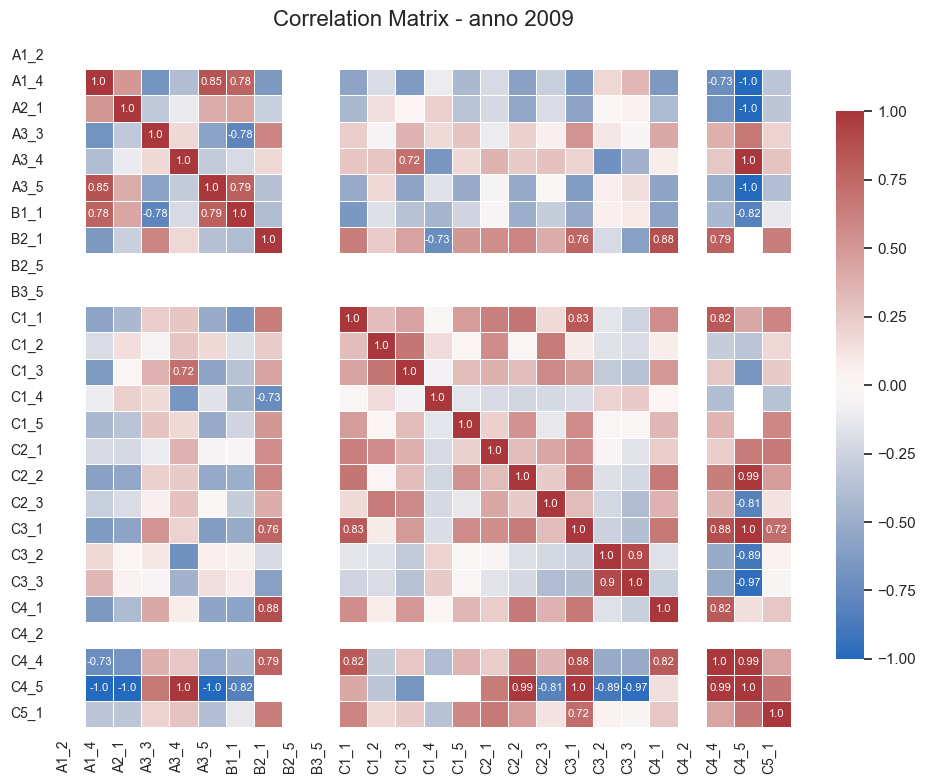

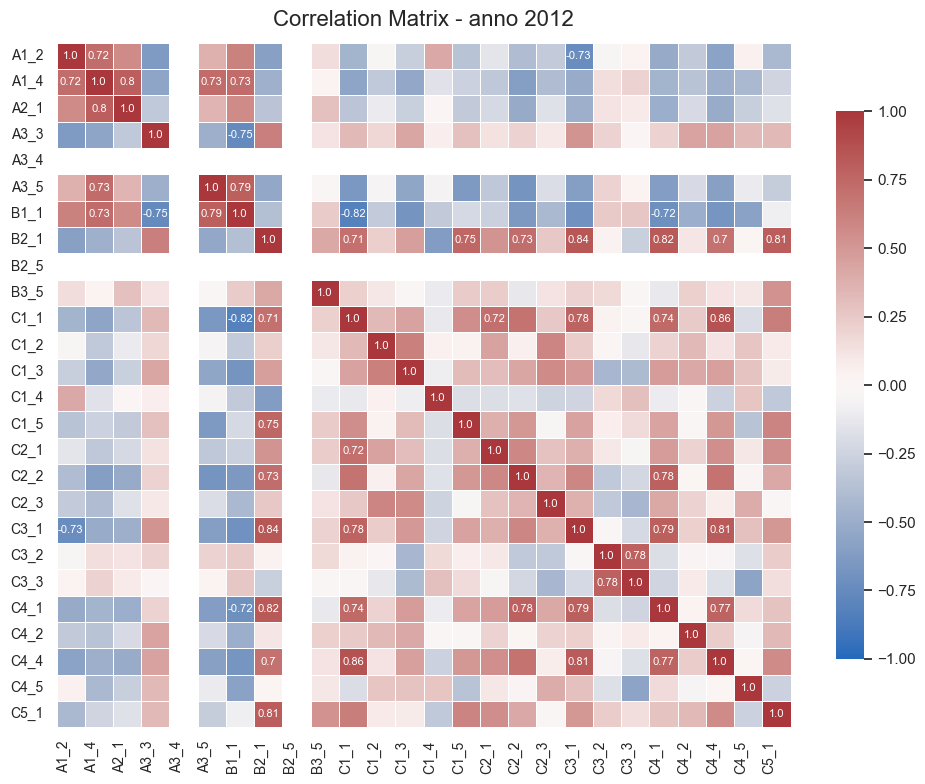

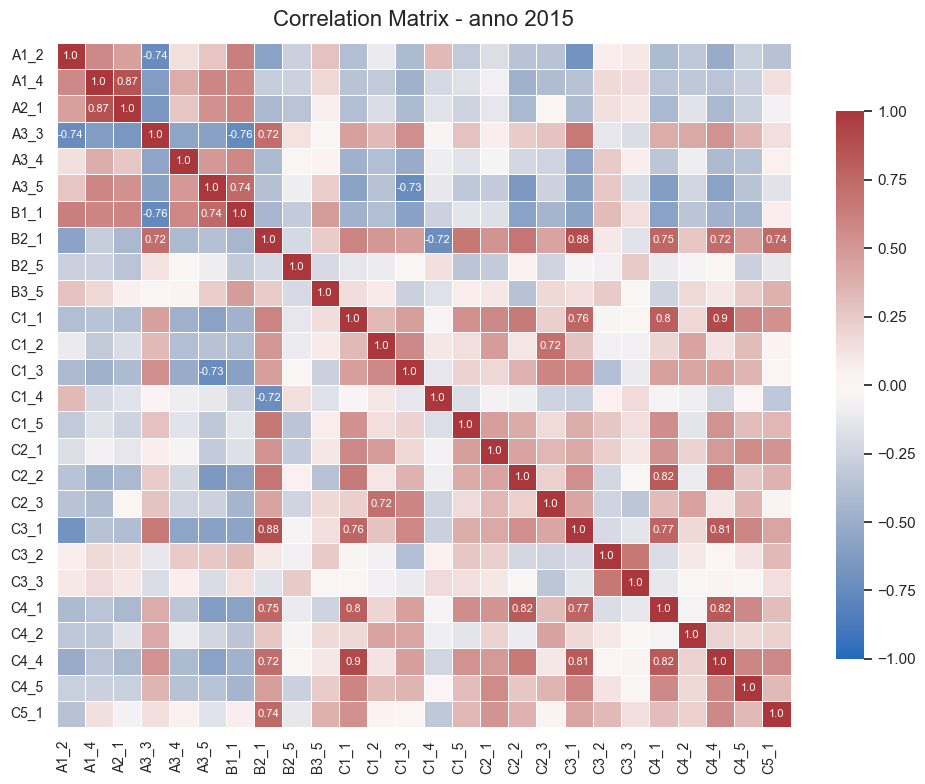

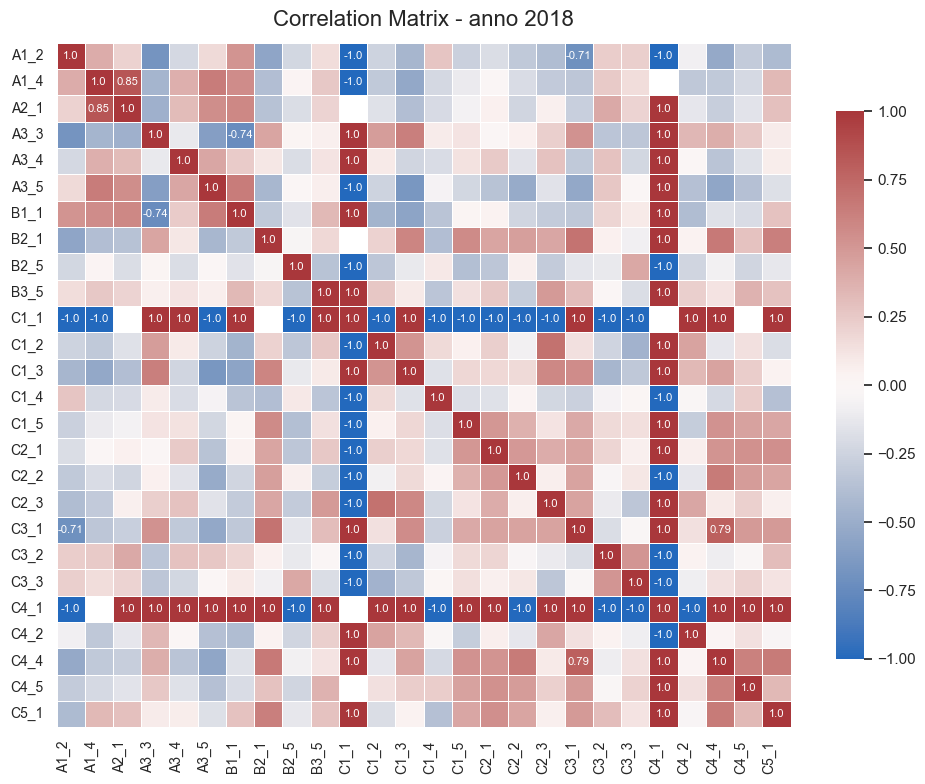

In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")  

for a, sub in df_per_anno.items():

    df = pd.DataFrame(sub).replace(to_replace="null", value=np.nan).iloc[:, 2:]
    col= sub.columns[2:]
    df.columns = col
    corr = df.corr()

    annot = corr.round(2).astype(str)
    annot = annot.where(corr.abs() > 0.7, "")

    plt.figure(figsize=(10, 8))

    ax = sns.heatmap(
        corr,
        cmap="vlag",         
        center=0,
        vmin=-1,
        vmax=1,
        annot=annot,
        fmt="",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"shrink": 0.8}, 
        annot_kws={"size": 8}, 

    )
    ax.set_title(f"Correlation Matrix - anno {a}", fontsize=16, pad=12)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right", fontsize=10)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

    plt.tight_layout()
    plt.show()


Split dei dataframe annuali in investimenti e outcome

In [93]:

chiavi = ["REF_AREA", "TIME_PERIOD"]

variabili_investimenti = [
    "C1_1",
    "C2_1", "C2_2", "C2_3",
    "C3_1", 
    "C4_4", "C4_5", 
    "C5_1"
]
variabili_investimenti_presenti = [
    c for c in variabili_investimenti
    if c in df_clean.columns
]

variabili_outcome_presenti = [
    c for c in df_clean.columns
    if c not in chiavi and c not in variabili_investimenti_presenti
]

print("Variabili investimenti presenti:", variabili_investimenti_presenti)
print("N investimenti:", len(variabili_investimenti_presenti))

print("\nVariabili outcome presenti:", variabili_outcome_presenti)
print("N outcome:", len(variabili_outcome_presenti))


Variabili investimenti presenti: ['C1_1', 'C2_1', 'C2_2', 'C2_3', 'C3_1', 'C4_4', 'C4_5', 'C5_1']
N investimenti: 8

Variabili outcome presenti: ['A1_2', 'A1_4', 'A2_1', 'A3_3', 'A3_4', 'A3_5', 'B1_1', 'B2_1', 'B2_5', 'B3_5', 'C1_2', 'C1_3', 'C1_4', 'C1_5', 'C3_2', 'C3_3', 'C4_1', 'C4_2']
N outcome: 18


In [94]:
df_investimenti_per_anno = {
    a: sub.select(chiavi + variabili_investimenti_presenti)
    for a, sub in df_per_anno.items()
}

df_outcome_per_anno = {
    a: sub.select(chiavi + variabili_outcome_presenti)
    for a, sub in df_per_anno.items()
}
